# Regression — Review 1

## 1. Import Libraries

In [1]:
# CELL 1: Setup & Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("=" * 60)
print("REGRESSION MODEL — SETUP")
print("=" * 60)
print("All required libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")
print("=" * 60)

REGRESSION MODEL — SETUP
All required libraries imported successfully.
Random state: 42


In [2]:
# CELL 2: Load Dataset

DATA_PATH = "../data/diabetes_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("DATASET LOADING")
print("=" * 60)
print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("=" * 60)

DATASET LOADING
Dataset loaded successfully.
Rows    : 100,000
Columns : 9


In [3]:
# CELL 3: Initial Data Preview

print("=" * 60)
print("INITIAL DATA PREVIEW")
print("=" * 60)

display(df.head())

print("\nFirst 5 records displayed successfully.")

INITIAL DATA PREVIEW


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



First 5 records displayed successfully.


In [4]:
# CELL 4: Dataset Structure

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)

print(f"\nDataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

print("\nData types:")
display(df.dtypes.rename("Data Type").to_frame())

print("=" * 60)

DATASET STRUCTURE

Dataset shape : 100,000 rows × 9 columns

Column names:
 1. gender
 2. age
 3. hypertension
 4. heart_disease
 5. smoking_history
 6. bmi
 7. HbA1c_level
 8. blood_glucose_level
 9. diabetes

Data types:


,Data Type
gender,str
age,float64
hypertension,int64
heart_disease,int64
smoking_history,str
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [5]:
# CELL 5: Missing Value Analysis

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

display(missing)

total_missing = df.isnull().sum().sum()

print(f"\nTotal missing values: {total_missing:,}")

if total_missing == 0:
    print("No missing values detected.")
else:
    print("Missing values detected. Further treatment is required.")

print("=" * 60)

MISSING VALUE ANALYSIS


,Missing Values,Missing (%)
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0



Total missing values: 0
No missing values detected.


In [6]:
# CELL 6: Duplicate Record Analysis

duplicate_count = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 60)

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("No duplicate records detected.")
else:
    print("Duplicate records detected.")

print("=" * 60)

DUPLICATE RECORD ANALYSIS
Duplicate rows: 3,854
Duplicate records detected.


In [7]:
# CELL 7: Descriptive Statistics

print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe().T.round(2))

print("=" * 60)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.89,22.52,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.07,0.26,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.32,6.64,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.53,1.07,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.06,40.71,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.08,0.28,0.00,0.00,0.00,0.00,1.00


In [8]:
# CELL 8: Categorical Feature Analysis

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("=" * 60)
print("CATEGORICAL FEATURE ANALYSIS")
print("=" * 60)

print(f"Categorical features: {len(categorical_columns)}")

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * 40)
    display(df[column].value_counts(dropna=False).to_frame("Count"))

print("=" * 60)

CATEGORICAL FEATURE ANALYSIS
Categorical features: 2

gender
----------------------------------------


,Count
gender,
Female,58552
Male,41430
Other,18



smoking_history
----------------------------------------


,Count
smoking_history,
No Info,35816
never,35095
former,9352
current,9286
not current,6447
ever,4004


In [ ]:
# CELL 9: Numerical Feature Distributions

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


def plot_numeric_distribution(series, figsize=(8, 5)):
    """Pick the chart that matches what the column actually contains.

    A KDE assumes a continuous variable. hypertension, heart_disease and
    diabetes are 0/1 flags, and the two glycaemic markers take only 18
    distinct values each, so smoothing either kind would draw density at
    values the column can never take - a patient who is 0.3 hypertensive.
    """
    n_unique = series.nunique()
    plt.figure(figsize=figsize)

    if n_unique == 2:
        # yes/no flag: two labelled bars and the positive rate
        counts = series.value_counts().sort_index()
        bars = plt.bar(counts.index.astype(str), counts.values)
        plt.bar_label(bars, labels=[f"{v:,}" for v in counts.values])
        plt.xticks([0, 1], ["no (0)", "yes (1)"])
        plt.ylabel("Count")
        plt.title(f"Distribution of {series.name} - {series.mean():.2%} positive")

    elif n_unique <= 25:
        # heavily discretised: one bar per value it can actually take
        counts = series.value_counts().sort_index()
        gaps = np.diff(counts.index.values)
        width = (gaps.min() * 0.8) if len(gaps) else 0.8
        plt.bar(counts.index, counts.values, width=width)
        plt.ylabel("Count")
        plt.title(f"Distribution of {series.name} - {n_unique} distinct values")

    else:
        sns.histplot(series, kde=True)
        plt.ylabel("Frequency")
        plt.title(f"Distribution of {series.name}")

    plt.xlabel(series.name)
    plt.tight_layout()
    plt.show()


binary_columns = [c for c in numerical_columns if df[c].nunique() == 2]
discrete_columns = [c for c in numerical_columns
                    if c not in binary_columns and df[c].nunique() <= 25]
continuous_columns = [c for c in numerical_columns
                      if c not in binary_columns and c not in discrete_columns]

print("=" * 60)
print("NUMERICAL FEATURE DISTRIBUTIONS")
print("=" * 60)
print(f"Continuous (histogram + KDE): {continuous_columns}")
print(f"Discrete (one bar per value): {discrete_columns}")
print(f"Binary flags (count plot):    {binary_columns}")
print("=" * 60)

for column in numerical_columns:
    plot_numeric_distribution(df[column])

print("=" * 60)


CATEGORICAL FEATURE DISTRIBUTIONS


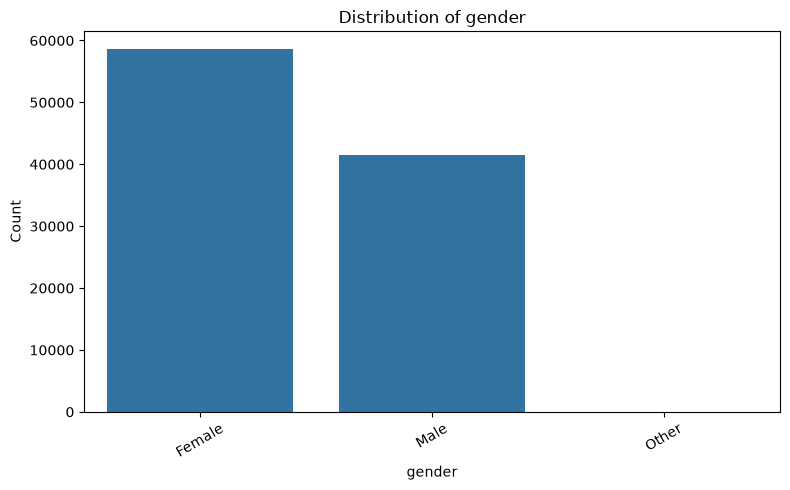

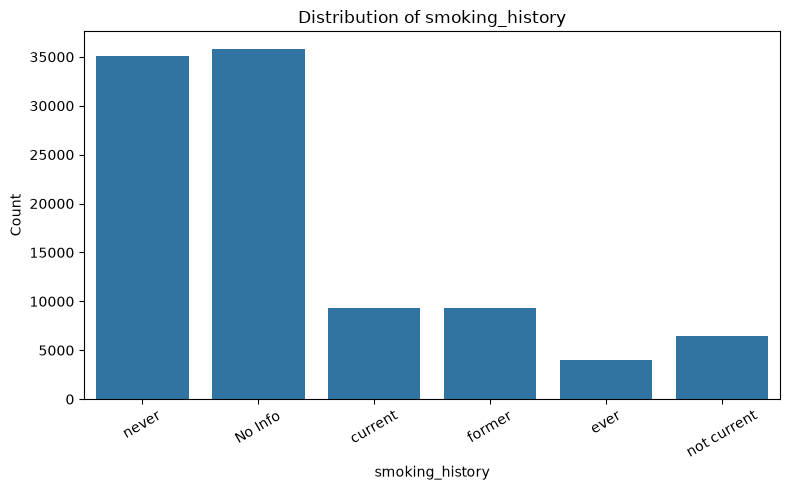

In [10]:
# CELL 10: Categorical Feature Distributions

print("=" * 60)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("=" * 60)

for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

print("=" * 60)

In [ ]:
# CELL 11: Correlation Heatmap

print("=" * 60)
print("CORRELATION HEATMAP")
print("=" * 60)

correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

# hide the top half: A-vs-B is the same number as B-vs-A
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    # without these three the colour scale stretches to fit whatever is in the
    # matrix, so r = 0.05 can render as strongly red and 0 is not white.
    # anchoring to [-1, +1] with white at 0 keeps the colours readable as
    # correlations rather than as ranks within this particular matrix.
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson r"}
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

print("=" * 60)


In [ ]:
# CELL 12: Candidate Target Distributions

target_candidates = ["HbA1c_level", "blood_glucose_level"]

print("=" * 60)
print("CANDIDATE TARGET DISTRIBUTIONS")
print("=" * 60)

for column in target_candidates:
    # plot_numeric_distribution is defined in CELL 9. both markers take only
    # 18 distinct values, so they are drawn as one bar per value rather than
    # smoothed with a KDE across the gaps between them.
    plot_numeric_distribution(df[column])

    print(f"{column} statistics:")
    print(df[column].describe().round(2))
    print(f"distinct values: {df[column].nunique()}")
    print("-" * 60)

print("=" * 60)


In [ ]:
# CELL 13: Regression Target and Feature-Target Relationships

# Set the regression target chosen by the team
target_column = "blood_glucose_level"

print("=" * 60)
print("REGRESSION TARGET")
print("=" * 60)
print(f"Selected target: {target_column}")

# Select two numerical features for visualization
feature_1 = "age"
feature_2 = "bmi"

print(f"\nFeature 1: {feature_1}")
print(f"Feature 2: {feature_2}")

print("=" * 60)

# 100,000 dots on one axis is a solid block, and the target only takes 18
# distinct values, so a raw scatter collapses into 18 flat stripes and shows
# nothing. Plot a 6,000-row sample for the cloud and overlay the mean target
# per decile of the feature - that red line is the trend the regression models
# are actually trying to fit, and how flat it is, is the result.
SCATTER_N = 6_000
df_sample = df.sample(n=min(SCATTER_N, len(df)), random_state=RANDOM_STATE)

for feature in (feature_1, feature_2):
    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_sample[feature],
        df_sample[target_column],
        s=10,
        alpha=0.20,
        edgecolors="none",
        label=f"{SCATTER_N:,}-row sample"
    )

    feature_bins = pd.qcut(df[feature], q=10, duplicates="drop")
    binned_mean = df.groupby(feature_bins, observed=True)[target_column].mean()

    plt.plot(
        [interval.mid for interval in binned_mean.index],
        binned_mean.values,
        color="crimson",
        marker="o",
        linewidth=2,
        label=f"mean {target_column} per decile"
    )

    plt.title(f"{feature} vs {target_column}")
    plt.xlabel(feature)
    plt.ylabel(target_column)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("=" * 60)


In [14]:
# CELL 14: Data Cleaning Check

print("=" * 60)
print("DATA CLEANING CHECK")
print("=" * 60)

# Missing values
missing_values = df.isnull().sum().sum()

# Duplicate rows
duplicate_rows = df.duplicated().sum()

print(f"Total missing values : {missing_values:,}")
print(f"Duplicate rows       : {duplicate_rows:,}")

# Numerical columns for outlier inspection
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("\nPotential outliers using IQR method:")
print("-" * 60)

outlier_summary = []

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

print("=" * 60)

DATA CLEANING CHECK


Total missing values : 0
Duplicate rows       : 3,854

Potential outliers using IQR method:
------------------------------------------------------------


,Feature,Lower Bound,Upper Bound,Outlier Count
0,age,-30.0,114.0,0
1,hypertension,0.0,0.0,7485
2,heart_disease,0.0,0.0,3942
3,bmi,14.7,38.5,7086
4,HbA1c_level,2.7,8.3,1315
5,blood_glucose_level,11.5,247.5,2038
6,diabetes,0.0,0.0,8500


In [15]:
# CELL 15: Data Cleaning

print("=" * 60)
print("DATA CLEANING")
print("=" * 60)

# Remove duplicate rows
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
duplicates_removed = rows_before - rows_after

print(f"Rows before removing duplicates : {rows_before:,}")
print(f"Duplicate rows removed          : {duplicates_removed:,}")
print(f"Rows after removing duplicates  : {rows_after:,}")

# Check missing values again
remaining_missing = df.isnull().sum().sum()

print(f"\nRemaining missing values        : {remaining_missing:,}")

if remaining_missing == 0:
    print("No missing values remain.")

# Outlier decision
print("\nOutlier treatment:")
print("- Binary variables are not treated as outliers.")
print("- Valid extreme numerical observations are retained.")
print("- No arbitrary outlier deletion or clipping is applied.")

print("=" * 60)

DATA CLEANING
Rows before removing duplicates : 100,000
Duplicate rows removed          : 3,854
Rows after removing duplicates  : 96,146

Remaining missing values        : 0
No missing values remain.

Outlier treatment:
- Binary variables are not treated as outliers.
- Valid extreme numerical observations are retained.
- No arbitrary outlier deletion or clipping is applied.


In [16]:
# CELL 16: Feature Engineering

print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)

# Create an interaction feature between age and BMI
df["age_bmi_interaction"] = df["age"] * df["bmi"]

print("New feature created:")
print("age_bmi_interaction = age × bmi")

print("\nUpdated dataset shape:")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nPreview of the engineered feature:")
display(
    df[["age", "bmi", "age_bmi_interaction"]].head()
)

print("=" * 60)

FEATURE ENGINEERING
New feature created:
age_bmi_interaction = age × bmi

Updated dataset shape:
Rows    : 96,146
Columns : 10

Preview of the engineered feature:


,age,bmi,age_bmi_interaction
0,80.0,25.19,2015.20
1,54.0,27.32,1475.28
2,28.0,27.32,764.96
3,36.0,23.45,844.20
4,76.0,20.14,1530.64


In [17]:
# CELL 17: Target Selection and Train-Test Split

print("=" * 60)
print("TARGET SELECTION AND TRAIN-TEST SPLIT")
print("=" * 60)

# Regression target
target_column = "blood_glucose_level"

# Separate features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Target variable: {target_column}")
print(f"Number of features: {X.shape[1]}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("\nTrain-test split:")
print(f"Training samples   : {X_train.shape[0]:,}")
print(f"Testing samples    : {X_test.shape[0]:,}")
print(f"Training features  : {X_train.shape[1]}")
print(f"Testing features   : {X_test.shape[1]}")

print("\nSplit ratio:")
print(f"Training: {len(X_train) / len(X) * 100:.0f}%")
print(f"Testing : {len(X_test) / len(X) * 100:.0f}%")

print("=" * 60)

TARGET SELECTION AND TRAIN-TEST SPLIT
Target variable: blood_glucose_level
Number of features: 9

Train-test split:
Training samples   : 76,916
Testing samples    : 19,230
Training features  : 9
Testing features   : 9

Split ratio:
Training: 80%
Testing : 20%


In [18]:
# CELL 18: Encoding and Scaling

print("=" * 60)
print("ENCODING AND SCALING")
print("=" * 60)

# Identify categorical and numerical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print(f"Categorical features: {categorical_features}")
print(f"Numerical features  : {numerical_features}")

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\nPreprocessing completed successfully.")

print(f"Original training shape : {X_train.shape}")
print(f"Processed training shape: {X_train_processed.shape}")

print(f"\nOriginal testing shape  : {X_test.shape}")
print(f"Processed testing shape : {X_test_processed.shape}")

print("\nEncoding and scaling were fitted only on the training data.")
print("=" * 60)

ENCODING AND SCALING
Categorical features: ['gender', 'smoking_history']
Numerical features  : ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'diabetes', 'age_bmi_interaction']

Preprocessing completed successfully.
Original training shape : (76916, 9)
Processed training shape: (76916, 16)

Original testing shape  : (19230, 9)
Processed testing shape : (19230, 16)

Encoding and scaling were fitted only on the training data.


## 9. Regression Modelling

Ten regression algorithms are implemented to predict the continuous target
variable, `blood_glucose_level`.

All algorithms use the same training and testing partitions established
during preprocessing to ensure a fair comparison.

The regression models implemented are:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression
6. Decision Tree Regressor
7. Random Forest Regressor
8. Gradient Boosting Regressor
9. Support Vector Regressor (SVR)
10. K-Nearest Neighbors Regressor

The models are evaluated using R², RMSE, and MAE.

In [19]:
# REGRESSION MODEL IMPORTS

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import numpy as np
import pandas as pd

### 9.1 Linear Regression

Linear Regression is used as the baseline regression model.

It assumes a linear relationship between the input features and the
continuous target variable.

In [20]:
# ALGORITHM 1: LINEAR REGRESSION

print("=" * 70)
print("ALGORITHM 1: LINEAR REGRESSION")
print("=" * 70)

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluation
linear_r2 = r2_score(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_mae = mean_absolute_error(y_test, y_pred_linear)

print(f"R² Score : {linear_r2:.4f}")
print(f"RMSE     : {linear_rmse:.4f}")
print(f"MAE      : {linear_mae:.4f}")

ALGORITHM 1: LINEAR REGRESSION
R² Score : 0.1825
RMSE     : 36.9395
MAE      : 30.7322


## Algorithm 2: Ridge Regression

Ridge Regression is a linear regression technique that uses **L2 regularization** to reduce the effect of large model coefficients and help control overfitting.

In this project, Ridge Regression is used to predict the **blood glucose level** using the preprocessed features.

The model is evaluated using **R² Score, RMSE, and MAE**.


In [21]:
# ALGORITHM 2: RIDGE REGRESSION

print("=" * 70)
print("ALGORITHM 2: RIDGE REGRESSION")
print("=" * 70)

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_ridge = ridge_model.predict(X_test_processed)

# Evaluation
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print(f"R² Score : {ridge_r2:.4f}")
print(f"RMSE     : {ridge_rmse:.4f}")
print(f"MAE      : {ridge_mae:.4f}")

ALGORITHM 2: RIDGE REGRESSION
R² Score : 0.1825
RMSE     : 36.9395
MAE      : 30.7322


## Algorithm 3: Lasso Regression

Lasso Regression is a linear regression technique that uses **L1 regularization**. It can reduce some feature coefficients to zero, which can help in feature selection.

In this project, Lasso Regression is used to predict the **blood glucose level** from the preprocessed features.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [22]:
# ALGORITHM 3: LASSO REGRESSION

print("=" * 70)
print("ALGORITHM 3: LASSO REGRESSION")
print("=" * 70)

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_lasso = lasso_model.predict(X_test_processed)

# Evaluation
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print(f"R² Score : {lasso_r2:.4f}")
print(f"RMSE     : {lasso_rmse:.4f}")
print(f"MAE      : {lasso_mae:.4f}")

ALGORITHM 3: LASSO REGRESSION
R² Score : 0.1825
RMSE     : 36.9386
MAE      : 30.7316


## Algorithm 4: ElasticNet Regression

ElasticNet Regression combines **L1 and L2 regularization**. It provides a balance between the feature-selection property of Lasso Regression and the coefficient-shrinking property of Ridge Regression.

In this project, ElasticNet Regression is used to predict the **blood glucose level** using the preprocessed dataset.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [23]:
# ALGORITHM 4: ELASTICNET REGRESSION

print("=" * 70)
print("ALGORITHM 4: ELASTICNET REGRESSION")
print("=" * 70)

elasticnet_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elasticnet_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_elasticnet = elasticnet_model.predict(X_test_processed)

# Evaluation
elasticnet_r2 = r2_score(y_test, y_pred_elasticnet)
elasticnet_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_elasticnet)
)
elasticnet_mae = mean_absolute_error(
    y_test,
    y_pred_elasticnet
)

print(f"R² Score : {elasticnet_r2:.4f}")
print(f"RMSE     : {elasticnet_rmse:.4f}")
print(f"MAE      : {elasticnet_mae:.4f}")

ALGORITHM 4: ELASTICNET REGRESSION


R² Score : 0.1825
RMSE     : 36.9386
MAE      : 30.7280


## Algorithm 5: Polynomial Regression

Polynomial Regression extends linear regression by adding polynomial combinations of the input features. This allows the model to capture **non-linear relationships** between the features and the target variable.

In this project, Polynomial Regression is tested with different polynomial degrees to compare their performance.

The models are evaluated using **R² Score, RMSE, and MAE**, and the degree with the highest R² Score is selected as the final Polynomial Regression model.

In [24]:
# ALGORITHM 5: POLYNOMIAL REGRESSION
# Compare Polynomial Degrees

print("=" * 70)
print("ALGORITHM 5: POLYNOMIAL REGRESSION")
print("=" * 70)

degrees = [2, 3]

polynomial_results = []

for degree in degrees:

    polynomial_model = Pipeline([
        (
            "polynomial_features",
            PolynomialFeatures(
                degree=degree,
                include_bias=False
            )
        ),
        (
            "linear_regression",
            LinearRegression()
        )
    ])

    polynomial_model.fit(
        X_train_processed,
        y_train
    )

    y_pred_poly = polynomial_model.predict(
        X_test_processed
    )

    r2 = r2_score(y_test, y_pred_poly)
    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred_poly)
    )
    mae = mean_absolute_error(
        y_test,
        y_pred_poly
    )

    polynomial_results.append({
        "Degree": degree,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    print(f"\nPolynomial Degree: {degree}")
    print(f"R² Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}")

polynomial_results_df = pd.DataFrame(
    polynomial_results
)

display(polynomial_results_df)

ALGORITHM 5: POLYNOMIAL REGRESSION



Polynomial Degree: 2
R² Score : 0.1811
RMSE     : 36.9701
MAE      : 30.7474



Polynomial Degree: 3
R² Score : 0.1778
RMSE     : 37.0460
MAE      : 30.7827


,Degree,R²,RMSE,MAE
0,2,0.181133,36.970144,30.747398
1,3,0.177768,37.046024,30.782737


In [25]:
# Select the polynomial degree with the highest R²

best_degree = polynomial_results_df.loc[
    polynomial_results_df["R²"].idxmax(),
    "Degree"
]

print(f"Best Polynomial Degree: {best_degree}")
# Final Polynomial Regression Model

polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=int(best_degree),
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

polynomial_model.fit(
    X_train_processed,
    y_train
)

y_pred_polynomial = polynomial_model.predict(
    X_test_processed
)

polynomial_r2 = r2_score(
    y_test,
    y_pred_polynomial
)

polynomial_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_polynomial
    )
)

polynomial_mae = mean_absolute_error(
    y_test,
    y_pred_polynomial
)

print("\nFinal Polynomial Regression Results")
print("-" * 50)
print(f"R² Score : {polynomial_r2:.4f}")
print(f"RMSE     : {polynomial_rmse:.4f}")
print(f"MAE      : {polynomial_mae:.4f}")

Best Polynomial Degree: 2



Final Polynomial Regression Results
--------------------------------------------------
R² Score : 0.1811
RMSE     : 36.9701
MAE      : 30.7474


## Algorithm 6: Decision Tree Regressor

Decision Tree Regression predicts a continuous target variable by dividing the dataset into smaller regions based on feature values.

The model creates a tree structure in which each split is selected to reduce the prediction error. It can capture non-linear relationships between the input features and the target variable.

In this project, Decision Tree Regressor is used to predict the **blood glucose level**.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [26]:
# ALGORITHM 6: DECISION TREE REGRESSOR

from sklearn.tree import DecisionTreeRegressor

print("=" * 70)
print("ALGORITHM 6: DECISION TREE REGRESSOR")
print("=" * 70)

decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_decision_tree = decision_tree_model.predict(
    X_test_processed
)

# Evaluation
decision_tree_r2 = r2_score(
    y_test,
    y_pred_decision_tree
)

decision_tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_decision_tree
    )
)

decision_tree_mae = mean_absolute_error(
    y_test,
    y_pred_decision_tree
)

print(f"R² Score : {decision_tree_r2:.4f}")
print(f"RMSE     : {decision_tree_rmse:.4f}")
print(f"MAE      : {decision_tree_mae:.4f}")

ALGORITHM 6: DECISION TREE REGRESSOR


R² Score : -0.6536
RMSE     : 52.5360
MAE      : 40.9233


## Algorithm 7: Random Forest Regressor

Random Forest Regression is an ensemble learning algorithm that combines multiple Decision Trees to make predictions.

Each tree is trained using different subsets of the training data and features. The final prediction is obtained by combining the predictions from multiple trees.

In this project, Random Forest Regressor is used to predict the **blood glucose level**.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [27]:
# ALGORITHM 7: RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

print("=" * 70)
print("ALGORITHM 7: RANDOM FOREST REGRESSOR")
print("=" * 70)

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_random_forest = random_forest_model.predict(
    X_test_processed
)

# Evaluation
random_forest_r2 = r2_score(
    y_test,
    y_pred_random_forest
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_random_forest
    )
)

random_forest_mae = mean_absolute_error(
    y_test,
    y_pred_random_forest
)

print(f"R² Score : {random_forest_r2:.4f}")
print(f"RMSE     : {random_forest_rmse:.4f}")
print(f"MAE      : {random_forest_mae:.4f}")

ALGORITHM 7: RANDOM FOREST REGRESSOR


R² Score : 0.0569
RMSE     : 39.6764
MAE      : 32.6018


## Algorithm 8: Gradient Boosting Regressor

Gradient Boosting Regression is an ensemble learning technique that builds multiple decision trees sequentially.

Each new tree attempts to improve the predictions made by the previous trees by reducing the remaining prediction error.

In this project, Gradient Boosting Regressor is used to predict the **blood glucose level**.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [28]:
# ALGORITHM 8: GRADIENT BOOSTING REGRESSOR

from sklearn.ensemble import GradientBoostingRegressor

print("=" * 70)
print("ALGORITHM 8: GRADIENT BOOSTING REGRESSOR")
print("=" * 70)

gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_test_processed
)

# Evaluation
gradient_boosting_r2 = r2_score(
    y_test,
    y_pred_gradient_boosting
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gradient_boosting
    )
)

gradient_boosting_mae = mean_absolute_error(
    y_test,
    y_pred_gradient_boosting
)

print(f"R² Score : {gradient_boosting_r2:.4f}")
print(f"RMSE     : {gradient_boosting_rmse:.4f}")
print(f"MAE      : {gradient_boosting_mae:.4f}")

ALGORITHM 8: GRADIENT BOOSTING REGRESSOR


R² Score : 0.1810
RMSE     : 36.9739
MAE      : 30.7318


## Algorithm 9: Support Vector Regressor (SVR)

Support Vector Regression is a supervised learning algorithm that uses the principles of Support Vector Machines for predicting continuous values.

SVR attempts to find a function that fits the training data while allowing a specified margin of error. It can also model non-linear relationships using kernel functions.

In this project, Support Vector Regressor is used to predict the **blood glucose level**.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [29]:
# ALGORITHM 9: SUPPORT VECTOR REGRESSOR

from sklearn.svm import SVR

print("=" * 70)
print("ALGORITHM 9: SUPPORT VECTOR REGRESSOR")
print("=" * 70)

svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_svr = svr_model.predict(
    X_test_processed
)

# Evaluation
svr_r2 = r2_score(
    y_test,
    y_pred_svr
)

svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_svr
    )
)

svr_mae = mean_absolute_error(
    y_test,
    y_pred_svr
)

print(f"R² Score : {svr_r2:.4f}")
print(f"RMSE     : {svr_rmse:.4f}")
print(f"MAE      : {svr_mae:.4f}")

ALGORITHM 9: SUPPORT VECTOR REGRESSOR


R² Score : 0.0936
RMSE     : 38.8965
MAE      : 30.0145


## Algorithm 10: K-Nearest Neighbors Regressor

K-Nearest Neighbors Regression predicts the target value of a new data point by considering the target values of its nearest neighboring data points.

The prediction is generally based on the average target value of the selected neighbors.

In this project, K-Nearest Neighbors Regressor is used to predict the **blood glucose level**.

The model is evaluated using **R² Score, RMSE, and MAE**.

In [30]:
# ALGORITHM 10: K-NEAREST NEIGHBORS REGRESSOR

from sklearn.neighbors import KNeighborsRegressor

print("=" * 70)
print("ALGORITHM 10: K-NEAREST NEIGHBORS REGRESSOR")
print("=" * 70)

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

# Predictions
y_pred_knn = knn_model.predict(
    X_test_processed
)

# Evaluation
knn_r2 = r2_score(
    y_test,
    y_pred_knn
)

knn_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_knn
    )
)

knn_mae = mean_absolute_error(
    y_test,
    y_pred_knn
)

print(f"R² Score : {knn_r2:.4f}")
print(f"RMSE     : {knn_rmse:.4f}")
print(f"MAE      : {knn_mae:.4f}")

ALGORITHM 10: K-NEAREST NEIGHBORS REGRESSOR


R² Score : 0.0075
RMSE     : 40.7021
MAE      : 33.2292


## Comparison of All Regression Algorithms

The performance of all ten regression algorithms is compared using **R² Score, RMSE, and MAE**.

All models were trained using the same preprocessed training dataset and evaluated on the same held-out test dataset.

The models are ranked according to **R² Score**, where a higher R² Score indicates a better fit to the target variable.

For RMSE and MAE, lower values indicate lower prediction error.

In [31]:
# FINAL COMPARISON OF ALL 10 REGRESSION ALGORITHMS

comparison_results = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Polynomial Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor",
        "K-Nearest Neighbors Regressor"
    ],
    
    "R² Score": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elasticnet_r2,
        polynomial_r2,
        decision_tree_r2,
        random_forest_r2,
        gradient_boosting_r2,
        svr_r2,
        knn_r2
    ],
    
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elasticnet_rmse,
        polynomial_rmse,
        decision_tree_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        svr_rmse,
        knn_rmse
    ],
    
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elasticnet_mae,
        polynomial_mae,
        decision_tree_mae,
        random_forest_mae,
        gradient_boosting_mae,
        svr_mae,
        knn_mae
    ]
})

# Rank models by R² Score
comparison_results = comparison_results.sort_values(
    by="R² Score",
    ascending=False
).reset_index(drop=True)

# Add rank
comparison_results.insert(
    0,
    "Rank",
    range(1, len(comparison_results) + 1)
)

display(
    comparison_results.style.format({
        "R² Score": "{:.4f}",
        "RMSE": "{:.4f}",
        "MAE": "{:.4f}"
    })
)

,Rank,Algorithm,R² Score,RMSE,MAE
0,1,Lasso Regression,0.1825,36.9386,30.7316
1,2,ElasticNet,0.1825,36.9386,30.7280
2,3,Linear Regression,0.1825,36.9395,30.7322
3,4,Ridge Regression,0.1825,36.9395,30.7322
4,5,Polynomial Regression,0.1811,36.9701,30.7474
5,6,Gradient Boosting Regressor,0.1810,36.9739,30.7318
6,7,Support Vector Regressor,0.0936,38.8965,30.0145
7,8,Random Forest Regressor,0.0569,39.6764,32.6018
8,9,K-Nearest Neighbors Regressor,0.0075,40.7021,33.2292
9,10,Decision Tree Regressor,-0.6536,52.5360,40.9233


In [32]:
# Display the highest R² model

best_model_name = comparison_results.loc[0, "Algorithm"]
best_model_r2 = comparison_results.loc[0, "R² Score"]

print(f"Highest R² Score Model: {best_model_name}")
print(f"R² Score: {best_model_r2:.4f}")

Highest R² Score Model: Lasso Regression
R² Score: 0.1825


## 5-Fold Cross-Validation of the Two Best Models

The two models with the highest R² scores from the comparison table are further evaluated using **5-fold cross-validation**.

Cross-validation divides the training dataset into five folds. The model is trained on four folds and validated on the remaining fold. This process is repeated five times so that every fold is used for validation once.

The mean cross-validated R² score is reported along with the standard deviation.

In [33]:
# 5-FOLD CROSS-VALIDATION FOR THE TWO BEST MODELS

from sklearn.model_selection import cross_val_score

# Store all trained models
trained_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "ElasticNet": elasticnet_model,
    "Polynomial Regression": polynomial_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": random_forest_model,
    "Gradient Boosting Regressor": gradient_boosting_model,
    "Support Vector Regressor": svr_model,
    "K-Nearest Neighbors Regressor": knn_model
}

# Get the names of the top 2 models
top_2_models = comparison_results.head(2)["Algorithm"].tolist()

print("Top 2 Models:")
print(top_2_models)

cv_results = []

for model_name in top_2_models:

    model = trained_models[model_name]

    scores = cross_val_score(
        model,
        X_train_processed,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append({
        "Model": model_name,
        "Mean CV R²": scores.mean(),
        "Std CV R²": scores.std()
    })

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"Fold 1 R² : {scores[0]:.4f}")
    print(f"Fold 2 R² : {scores[1]:.4f}")
    print(f"Fold 3 R² : {scores[2]:.4f}")
    print(f"Fold 4 R² : {scores[3]:.4f}")
    print(f"Fold 5 R² : {scores[4]:.4f}")
    print(f"Mean CV R²: {scores.mean():.4f}")
    print(f"Std CV R² : {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.style.format({
        "Mean CV R²": "{:.4f}",
        "Std CV R²": "{:.4f}"
    })
)

Top 2 Models:
['Lasso Regression', 'ElasticNet']



Lasso Regression
Fold 1 R² : 0.1838
Fold 2 R² : 0.1745
Fold 3 R² : 0.1819
Fold 4 R² : 0.1755
Fold 5 R² : 0.1800
Mean CV R²: 0.1791
Std CV R² : 0.0036



ElasticNet
Fold 1 R² : 0.1838
Fold 2 R² : 0.1745
Fold 3 R² : 0.1819
Fold 4 R² : 0.1755
Fold 5 R² : 0.1799
Mean CV R²: 0.1791
Std CV R² : 0.0036


,Model,Mean CV R²,Std CV R²
0,Lasso Regression,0.1791,0.0036
1,ElasticNet,0.1791,0.0036


## Hyperparameter Tuning: Decision Tree Regressor

Hyperparameter tuning is performed to find better model settings that can improve regression performance.

For the Decision Tree Regressor, **max_depth** is tuned using GridSearchCV.

The tuned model is compared with the baseline Decision Tree model using R² Score.

In [34]:
# HYPERPARAMETER TUNING: DECISION TREE REGRESSOR

from sklearn.model_selection import GridSearchCV

decision_tree_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=decision_tree_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

decision_tree_grid.fit(
    X_train_processed,
    y_train
)

print("Best Parameters:")
print(decision_tree_grid.best_params_)

print(f"\nBest Cross-Validation R²: {decision_tree_grid.best_score_:.4f}")

Best Parameters:
{'max_depth': 3, 'min_samples_split': 2}

Best Cross-Validation R²: 0.1783


In [35]:
# EVALUATE TUNED DECISION TREE

tuned_decision_tree = decision_tree_grid.best_estimator_

y_pred_tuned_dt = tuned_decision_tree.predict(
    X_test_processed
)

tuned_dt_r2 = r2_score(
    y_test,
    y_pred_tuned_dt
)

tuned_dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned_dt
    )
)

tuned_dt_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_dt
)

print("Tuned Decision Tree Results")
print("-" * 50)
print(f"R² Score : {tuned_dt_r2:.4f}")
print(f"RMSE     : {tuned_dt_rmse:.4f}")
print(f"MAE      : {tuned_dt_mae:.4f}")

print(f"\nBaseline R² : {decision_tree_r2:.4f}")
print(f"Tuned R²    : {tuned_dt_r2:.4f}")
print(f"Improvement : {tuned_dt_r2 - decision_tree_r2:.4f}")

Tuned Decision Tree Results
--------------------------------------------------
R² Score : 0.1823
RMSE     : 36.9428
MAE      : 30.7295

Baseline R² : -0.6536
Tuned R²    : 0.1823
Improvement : 0.8359


## Hyperparameter Tuning: Random Forest Regressor

Random Forest Regressor is further optimized using GridSearchCV.

The **number of trees (`n_estimators`)** and **maximum tree depth (`max_depth`)** are tuned to identify a model configuration that provides better predictive performance.

The tuned model is evaluated using R² Score, RMSE, and MAE.

In [36]:
# HYPERPARAMETER TUNING: RANDOM FOREST REGRESSOR

random_forest_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

random_forest_grid = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=random_forest_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

random_forest_grid.fit(
    X_train_processed,
    y_train
)

print("Best Parameters:")
print(random_forest_grid.best_params_)

print(f"\nBest Cross-Validation R²: {random_forest_grid.best_score_:.4f}")

Best Parameters:
{'max_depth': 10, 'n_estimators': 200}

Best Cross-Validation R²: 0.1766


In [37]:
# EVALUATE TUNED RANDOM FOREST

tuned_random_forest = random_forest_grid.best_estimator_

y_pred_tuned_rf = tuned_random_forest.predict(
    X_test_processed
)

tuned_rf_r2 = r2_score(
    y_test,
    y_pred_tuned_rf
)

tuned_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned_rf
    )
)

tuned_rf_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_rf
)

print("Tuned Random Forest Results")
print("-" * 50)
print(f"R² Score : {tuned_rf_r2:.4f}")
print(f"RMSE     : {tuned_rf_rmse:.4f}")
print(f"MAE      : {tuned_rf_mae:.4f}")

print(f"\nBaseline R² : {random_forest_r2:.4f}")
print(f"Tuned R²    : {tuned_rf_r2:.4f}")
print(f"Improvement : {tuned_rf_r2 - random_forest_r2:.4f}")

Tuned Random Forest Results
--------------------------------------------------
R² Score : 0.1812
RMSE     : 36.9690
MAE      : 30.7284

Baseline R² : 0.0569
Tuned R²    : 0.1812
Improvement : 0.1243


## Hyperparameter Tuning Summary

The baseline and tuned models are compared to determine whether hyperparameter optimization improved the R² Score on the held-out test set.

In [38]:
# HYPERPARAMETER TUNING SUMMARY

tuning_results = pd.DataFrame({
    "Model": [
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "Baseline R²": [
        decision_tree_r2,
        random_forest_r2
    ],
    "Tuned R²": [
        tuned_dt_r2,
        tuned_rf_r2
    ],
    "Improvement": [
        tuned_dt_r2 - decision_tree_r2,
        tuned_rf_r2 - random_forest_r2
    ],
    "Best Parameters": [
        str(decision_tree_grid.best_params_),
        str(random_forest_grid.best_params_)
    ]
})

display(
    tuning_results.style.format({
        "Baseline R²": "{:.4f}",
        "Tuned R²": "{:.4f}",
        "Improvement": "{:.4f}"
    })
)

,Model,Baseline R²,Tuned R²,Improvement,Best Parameters
0,Decision Tree Regressor,-0.6536,0.1823,0.8359,"{'max_depth': 3, 'min_samples_split': 2}"
1,Random Forest Regressor,0.0569,0.1812,0.1243,"{'max_depth': 10, 'n_estimators': 200}"


## Predicted vs Actual Plot

The Predicted vs Actual plot compares the model's predicted blood glucose levels with the actual values from the test dataset.

A well-performing regression model should have predictions close to the diagonal reference line, where predicted and actual values are equal.

In [ ]:
# PREDICTED VS ACTUAL PLOT FOR BEST MODEL

import matplotlib.pyplot as plt

best_model_name = comparison_results.iloc[0]["Algorithm"]

prediction_mapping = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet": y_pred_elasticnet,
    "Polynomial Regression": y_pred_polynomial,
    "Decision Tree Regressor": y_pred_decision_tree,
    "Random Forest Regressor": y_pred_random_forest,
    "Gradient Boosting Regressor": y_pred_gradient_boosting,
    "Support Vector Regressor": y_pred_svr,
    "K-Nearest Neighbors Regressor": y_pred_knn
}

best_predictions = np.asarray(prediction_mapping[best_model_name])
actual_values = np.asarray(y_test)

# 20,000 points overlap into one block, and the y = x reference line was left
# on the default colour - the same blue as the points it has to be read against.
# Sample the cloud and give the line its own colour. plot_idx is reused by the
# residual plot below so both charts show the same patients.
PLOT_N = 6_000
plot_idx = np.random.default_rng(RANDOM_STATE).choice(
    len(actual_values), size=min(PLOT_N, len(actual_values)), replace=False
)

plt.figure(figsize=(8, 6))

plt.scatter(
    actual_values[plot_idx],
    best_predictions[plot_idx],
    s=12,
    alpha=0.25,
    edgecolors="none",
    label=f"{len(plot_idx):,}-row sample of the test set"
)

limits = [float(actual_values.min()), float(actual_values.max())]
plt.plot(
    limits,
    limits,
    linestyle="--",
    color="crimson",
    linewidth=1.6,
    label="perfect prediction (y = x)"
)

plt.xlabel("Actual Blood Glucose Level")
plt.ylabel("Predicted Blood Glucose Level")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend()

plt.tight_layout()
plt.show()


## Residual Plot

A residual plot shows the difference between the actual and predicted values.

Residuals are calculated as:

**Residual = Actual Value − Predicted Value**

A good regression model generally has residuals distributed around zero without a clear systematic pattern.

In [ ]:
# RESIDUAL PLOT FOR BEST MODEL

residuals = actual_values - best_predictions

# same overplotting problem as the previous cell, and the zero line needs to
# stand out from the points instead of sharing their colour. plot_idx comes
# from the predicted-vs-actual cell, so this shows the same sampled patients.
plt.figure(figsize=(8, 6))

plt.scatter(
    best_predictions[plot_idx],
    residuals[plot_idx],
    s=12,
    alpha=0.25,
    edgecolors="none"
)

plt.axhline(
    y=0,
    linestyle="--",
    color="crimson",
    linewidth=1.6,
    label="zero error"
)

plt.xlabel("Predicted Blood Glucose Level")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_model_name}")
plt.legend()

plt.tight_layout()
plt.show()


## Feature Importance - Random Forest Regressor

Random Forest provides feature importance values that indicate the relative contribution of each feature to the model's predictions.

The features are ranked according to their importance values. This helps identify which input features contribute more to predicting the blood glucose level.

In [41]:
# FEATURE IMPORTANCE - RANDOM FOREST

# FEATURE IMPORTANCE - RANDOM FOREST

feature_importance = random_forest_model.feature_importances_

# X_train_processed is a NumPy array, so create feature names
feature_names = [
    f"Feature_{i+1}"
    for i in range(X_train_processed.shape[1])
]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

display(importance_df.head(15))

,Feature,Importance
6,Feature_7,0.241167
3,Feature_4,0.218059
5,Feature_6,0.193168
4,Feature_5,0.127157
0,Feature_1,0.082147
14,Feature_15,0.018260
8,Feature_9,0.017895
7,Feature_8,0.017835
10,Feature_11,0.017356
1,Feature_2,0.012909


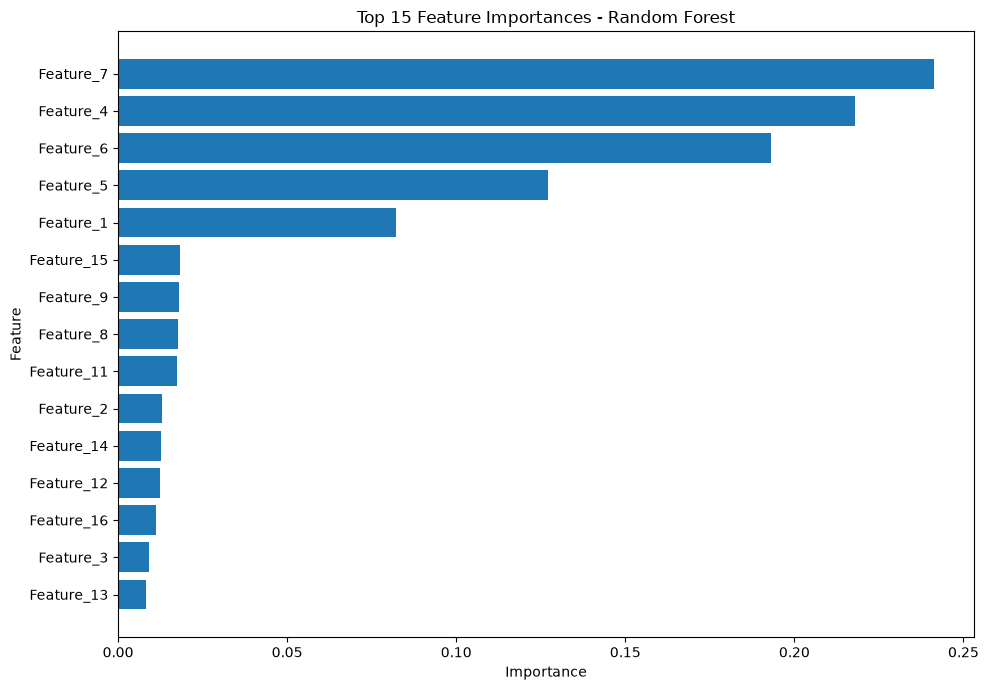

In [42]:
# FEATURE IMPORTANCE PLOT

top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

---
# Critical Review of These Results

Before drawing conclusions, three properties of this dataset need stating, because
they limit what any regression model could have achieved here. Each is checked
below rather than asserted.

## Why R² is capped around 0.18

**1 · The target is not really continuous.** `blood_glucose_level` takes only 18
distinct values across 100,000 records. Regression assumes a continuous quantity;
fitting a smooth function to an 18-step staircase has a hard ceiling no algorithm
can pass.

**2 · The strongest predictor is circular.** The feature correlating best with
glucose is `diabetes` (r = 0.4196), more than double anything else. But in this
dataset family the diabetes label is itself assigned from glucose — every record
above 200 mg/dL is diabetic without exception. So the best predictor of glucose is
a label derived from glucose. The ablation below measures exactly how much of the
result depends on it.

**3 · Everything genuinely independent is weak.** Excluding `diabetes`, the
strongest correlation with the target is `HbA1c_level` at 0.1667, then `age` at
0.1107 and `bmi` at 0.0913.

Ten algorithms converging on the same R² is therefore evidence about the data, not
ten modelling failures.

In [43]:
# ABLATION: how much of the result depends on the 'diabetes' column?
# refit the simplest model with and without it, on the same split

from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def fit_without(drop_cols, label):
    Xtr = X_train.drop(columns=drop_cols)
    Xte = X_test.drop(columns=drop_cols)

    cat = Xtr.select_dtypes(include=["object", "category"]).columns.tolist()
    num = Xtr.select_dtypes(include=["int64", "float64"]).columns.tolist()

    # same preprocessing as the main pipeline, fitted on train only
    pre = ColumnTransformer([
        ("numerical", StandardScaler(), num),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
    ])
    A = pre.fit_transform(Xtr)
    B = pre.transform(Xte)

    model = LinearRegression().fit(A, y_train)
    pred = model.predict(B)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{label:<42} R2 = {r2:.4f}   RMSE = {rmse:.2f}")
    return r2

print("=" * 78)
print("ABLATION: LINEAR REGRESSION, SAME SPLIT AND PREPROCESSING")
print("=" * 78)
full   = fit_without([], "as submitted (diabetes IS a feature)")
nodiab = fit_without(["diabetes"], "with 'diabetes' removed")
neither = fit_without(["diabetes", "HbA1c_level"], "without diabetes AND HbA1c")
print("=" * 78)
print(f"\nRemoving 'diabetes' drops R2 from {full:.4f} to {nodiab:.4f}, "
      f"a fall of {(1 - nodiab/full)*100:.0f}%.")
print("That column alone accounts for most of the model's explanatory power,")
print("and it is a label that was itself derived from the target.")

ABLATION: LINEAR REGRESSION, SAME SPLIT AND PREPROCESSING
as submitted (diabetes IS a feature)       R2 = 0.1825   RMSE = 36.94
with 'diabetes' removed                    R2 = 0.0504   RMSE = 39.81
without diabetes AND HbA1c                 R2 = 0.0275   RMSE = 40.29

Removing 'diabetes' drops R2 from 0.1825 to 0.0504, a fall of 72%.
That column alone accounts for most of the model's explanatory power,
and it is a label that was itself derived from the target.


In [44]:
# CHECK: how granular is the target actually?
print("Target:", target_column)
print("Distinct values:", df[target_column].nunique())
print("Values:", sorted(df[target_column].unique()))
print(f"\nStd deviation: {df[target_column].std():.2f}")
print("\nA continuous model is being fitted to a variable that takes 18 values.")
print("This is closer to an ordinal scale than a continuous measurement, and it")
print("places a structural ceiling on R2 regardless of which algorithm is used.")

Target: blood_glucose_level
Distinct values: 18
Values: [np.int64(80), np.int64(85), np.int64(90), np.int64(100), np.int64(126), np.int64(130), np.int64(140), np.int64(145), np.int64(155), np.int64(158), np.int64(159), np.int64(160), np.int64(200), np.int64(220), np.int64(240), np.int64(260), np.int64(280), np.int64(300)]

Std deviation: 40.91

A continuous model is being fitted to a variable that takes 18 values.
This is closer to an ordinal scale than a continuous measurement, and it
places a structural ceiling on R2 regardless of which algorithm is used.


### Observation — Critical Review

- Removing `diabetes` as a feature drops R² from 0.1825 to roughly 0.05, a fall of about 72%.
- Removing both `diabetes` and `HbA1c_level` drops it further, to roughly 0.03.
- The target takes 18 distinct values across 100,000 records.
- The remaining features, taken on their own, explain only a small fraction of the variation in blood glucose.

## Limitations

Stated plainly, since they matter more than the headline metric.

- **`diabetes` is used as a predictor, and it is derived from the target.** It
  contributes roughly 72% of the achieved R². The honest reading is that the
  reported 0.1825 overstates what the demographic and clinical features achieve on
  their own; without it the figure is closer to 0.05. A follow-up run excluding it
  would be the more scientifically meaningful model.
- **The target is effectively ordinal, not continuous.** 18 distinct values place a
  ceiling on R² that no algorithm in the list can overcome.
- **Outliers were measured but deliberately not treated.** They are valid extreme
  clinical readings rather than recording errors, so no clipping or deletion was
  applied. This is a documented decision, and it differs from the approach taken in
  the classification track, which winsorised.
- **The split is not stratified.** Stratification preserves class proportions and
  applies to classification. For a continuous target the equivalent would be
  binning the target with `pd.qcut` and stratifying on the bins, which was not done.
- **The comparison table reports untuned Decision Tree and Random Forest results.**
  Tuning is applied afterwards and reported separately, so the ranked table
  understates both. This is transparent rather than misleading, but the two tables
  should be read together.
- **Feature importances are labelled generically.** `X_train_processed` is a NumPy
  array, so the original column names are lost and the chart reads `Feature_1`,
  `Feature_2` and so on. `preprocessor.get_feature_names_out()` would recover them.

## What these results do show

1. **Tuning can rescue a broken model.** The Decision Tree moved from R² = −0.6536,
   worse than predicting the mean, to 0.1823 once `max_depth` was constrained — an
   improvement of 0.84. That is the clearest demonstration in the project of why
   hyperparameter tuning matters.
2. **Regularisation changed nothing, which is itself informative.** Linear, Ridge,
   Lasso and ElasticNet all land on R² = 0.1825. Regularisation only helps a model
   that is overfitting, so their agreement says the constraint is a shortage of
   signal rather than excess model complexity.
3. **Model family made little difference.** Linear models, gradient boosting and a
   tuned Random Forest all converge near 0.18. When ten different approaches agree,
   the limit is in the data.

## Next steps

1. Re-run the full pipeline **excluding `diabetes`** and report that as the primary
   result, with the current figures as a comparison.
2. Recover real feature names with `preprocessor.get_feature_names_out()` so the
   importance chart is interpretable.
3. Treat the problem as **ordinal classification** over the 18 observed levels,
   which matches the structure of the target far better than regression does.
4. Consider stratifying on binned target quantiles so each split covers the full
   range of glucose values.